/var/folders/lx/0h760fjj75g65qlknyyvp6y00000gp/T/ipykernel_7540/3972242295.py:51: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node = create_react_agent(llm,tools=Tools)


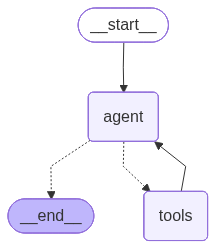

In [1]:
from langgraph.graph import StateGraph,END
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import Annotated,Sequence
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_community.tools import Tool
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langgraph.prebuilt import create_react_agent
from typing import TypedDict,Sequence,Annotated
from langgraph.graph import add_messages
from langchain_core.messages import HumanMessage,BaseMessage

def make_retrieval_tool_from_text(file,name,desc):
    docs = TextLoader(file,encoding="utf-8").load()
    split_docs = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
    chunks = split_docs.split_documents(docs)
    vs = FAISS.from_documents(documents=chunks,embedding=OpenAIEmbeddings())
    retriever = vs.as_retriever()

    def tool_func(query:str)->str:
        print(f"Using function {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name,description=desc,func=tool_func)

def arxiv_search(query:str)->str:
    api_wrapper = ArxivAPIWrapper()
    arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
    return arxiv.run(query)

arxiv_tool = Tool(name="Arxiv",description="To search arxiv DB",func=arxiv_search)

def wiki_search(query:str)->str:
    api_wrapper = WikipediaAPIWrapper()
    wiki = WikipediaQueryRun(api_wrapper=api_wrapper)
    return wiki.run(query)

wiki_tool = Tool(name="Wiki",description="This is used to search Web",func=wiki_search)

internal_tool1=make_retrieval_tool_from_text("internaldocs.txt","Internal_Tool1","Tool to know about transformers")

internal_tool2=make_retrieval_tool_from_text("internaldocs_2.txt","Internal_Tool2","Tool to search about agents")

Tools = [internal_tool1,internal_tool2,arxiv_tool,wiki_tool]

llm = ChatOpenAI(model="gpt-4o-mini")

react_node = create_react_agent(llm,tools=Tools)

react_node


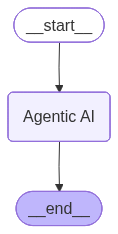

In [8]:
class AgentState(TypedDict):
    messages : Annotated[Sequence[BaseMessage],add_messages]

builder = StateGraph(AgentState)

builder.add_node("Agentic AI",react_node)

builder.set_entry_point("Agentic AI")

builder.add_edge("Agentic AI",END)

graph = builder.compile()

graph



In [10]:
query = "What do our internal research notes say about transformer variants,and what does Arxiv suggest recently"

result = graph.invoke({"messages":[HumanMessage(content=query)]})

print(result['messages'][-1].content)

Using function Internal_Tool1
### Internal Research Notes on Transformer Variants

Transformers are a class of neural network architectures extensively used in natural language processing (NLP), computer vision, and generative AI. They employ an attention mechanism that focuses on the relevant parts of the input data to generate outputs. Following the introduction of the transformer architecture in the seminal paper "Attention Is All You Need" by Ashish Vaswani, various transformer variants have emerged to enhance performance, efficiency, scalability, and specialization for specific tasks.

#### Major Transformer Variants

1. **Encoder-Based Transformers**
   - **Examples**: BERT (Bidirectional Encoder Representations from Transformers) by Google.
   - **Key Characteristics**:
     - Bidirectional context understanding.
     - Strong performance on classification and question-answering tasks.
     - Pretrained on large datasets and fine-tuned for specific tasks.
   - **Applications**: 

In [ ]:
class RAGCOTSTATE(BaseModel):
    question : str
    sub_steps : List[str] = []
    answer : str = ""
    retrieved_docs = List[Document] = []

def plan_steps(state:RAGCOTSTATE)->RAGCOTSTATE:
    prompt = f"Break the question into 2-3 reasoning Steps:\n\n {state.question}"
    result = llm.invoke(prompt).content
    sub_qs = [line.strip("-") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_steps":sub_qs})

def retriever_per_step(state:RAGCOTSTATE)->RAGCOTSTATE:
    all_docs = []
    for sub in state.sub_steps:
        doc = retriever.invoke(sub)
        all_docs.extend(doc)
    return state.model_copy(update={"retrieved_docs":all_docs})